In [1]:
# --- Celda 1: Instalaciones e Importaciones ---
# (Opcional) Instala joblib si no estuviera disponible, aunque en Colab ya viene.
# !pip install joblib pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # Lo usaremos solo para cargar/guardar el modelo al final si quieres
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap

print("Librerías importadas.")

Librerías importadas.


In [2]:
# --- Celda 2: Definición de Funciones Auxiliares ---

def visualizar_datos_iniciales(df):
    """
    Crea un scatter plot inicial de los datos.
    """
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Productos-Lote', y='Tiempo-Entrega', hue='Defectuoso', style='Defectuoso', s=100, palette='coolwarm')
    plt.title('Visualización Inicial de Datos\n(0 = No Defectuoso, 1 = Defectuoso)')
    plt.xlabel('Productos por Lote')
    plt.ylabel('Tiempo de Entrega (Estimado)')
    plt.legend(title='Defectuoso')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig("visualizacion_inicial.png") # Guarda la imagen en Colab
    plt.show() # Muestra la imagen en la salida de la celda
    print("Gráfico 'visualizacion_inicial.png' guardado y mostrado.")

def plot_decision_boundary(X, y, model, scaler, X_train, y_train):
    """
    Dibuja la frontera de decisión del modelo.
    """
    X_plot = X_train.values
    y_plot = y_train.values

    cmap_light = ListedColormap(['#AAAAFF', '#FFAAAA']) # Azul claro para 0, Rojo claro para 1
    cmap_bold = ['blue', 'red']

    padding_x = (X_plot[:, 0].max() - X_plot[:, 0].min()) * 0.1
    padding_y = (X_plot[:, 1].max() - X_plot[:, 1].min()) * 0.1

    x_min, x_max = X_plot[:, 0].min() - padding_x, X_plot[:, 0].max() + padding_x
    y_min, y_max = X_plot[:, 1].min() - padding_y, X_plot[:, 1].max() + padding_y

    h1_step = (x_max - x_min) / 100
    h2_step = (y_max - y_min) / 100
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h1_step),
                         np.arange(y_min, y_max, h2_step))

    grid_data = np.c_[xx.ravel(), yy.ravel()]
    grid_df = pd.DataFrame(grid_data, columns=X_train.columns)
    grid_scaled = scaler.transform(grid_df)
    Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

    sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], hue=y_plot,
                    palette=cmap_bold, alpha=1.0, edgecolor="black", s=80)

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Frontera de Decisión (Datos de Entrenamiento)")
    plt.xlabel("Productos por Lote")
    plt.ylabel("Tiempo de Entrega (Estimado)")

    h, l = plt.gca().get_legend_handles_labels()
    new_labels = ['0 - No Defectuoso', '1 - Defectuoso']
    if len(h) >= 2:
        plt.legend(handles=h[:2], labels=new_labels, title="Clase Real")
    else:
         plt.legend(title="Clase Real")

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig("frontera_decision.png")
    plt.show()
    print("Gráfico 'frontera_decision.png' guardado y mostrado.")

def plot_confusion_matrix_metric(y_test, y_pred, labels):
    """
    Dibuja la matriz de confusión.
    """
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title("Matriz de Confusión (Datos de Prueba)")
    plt.tight_layout()
    plt.savefig("matriz_confusion.png")
    plt.show()
    print("Gráfico 'matriz_confusion.png' guardado y mostrado.")

def predecir_interactivo(model, scaler, columns):
    """
    Permite al usuario ingresar datos de forma interactiva
    para realizar predicciones en un bucle.
    """
    print("\n--- PREDICCIONES INTERACTIVAS ---")
    print("--- Introduce los datos del nuevo lote ---")
    while True:
        try:
            productos_str = input(f"Introduce la cantidad '{columns[0]}' (o 'salir' para terminar): ")
            if productos_str.lower() == 'salir':
                break

            tiempo_str = input(f"Introduce el '{columns[1]}': ")
            if tiempo_str.lower() == 'salir':
                break

            productos = float(productos_str)
            tiempo = float(tiempo_str)

            dato_nuevo = np.array([[productos, tiempo]])
            dato_df = pd.DataFrame(dato_nuevo, columns=columns)
            dato_scaled = scaler.transform(dato_df)

            prediccion = model.predict(dato_scaled)
            probabilidades = model.predict_proba(dato_scaled)

            clase_predicha = prediccion[0]
            prob_clase_0 = probabilidades[0][0]
            prob_clase_1 = probabilidades[0][1]
            resultado = "Defectuoso" if clase_predicha == 1 else "No Defectuoso"

            print("\n--- Resultado de la Predicción ---")
            print(f"  > Datos: {columns[0]}={productos}, {columns[1]}={tiempo}")
            print(f"  > Resultado: {clase_predicha} ({resultado})")
            print(f"  > Confianza (No Defectuoso): {prob_clase_0:.2%}")
            print(f"  > Confianza (Defectuoso):   {prob_clase_1:.2%}")
            print("----------------------------------\n")

        except ValueError:
            print("\n[Error] Por favor, introduce solo números. Intenta de nuevo.\n")
        except Exception as e:
            print(f"\n[Error inesperado] {e}\n")

    print("Fin del modo de predicción.")

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


Cargando datos desde 'datos_logisticos.xlsx'...
Datos cargados exitosamente.
   Muestra  Productos-Lote  Tiempo-Entrega  Defectuoso
0        1              19           19000           0
1        2              35           20000           0
2        3              26           43000           0
3        4              27           57000           0
4        5              19           76000           0

Generando visualización inicial...


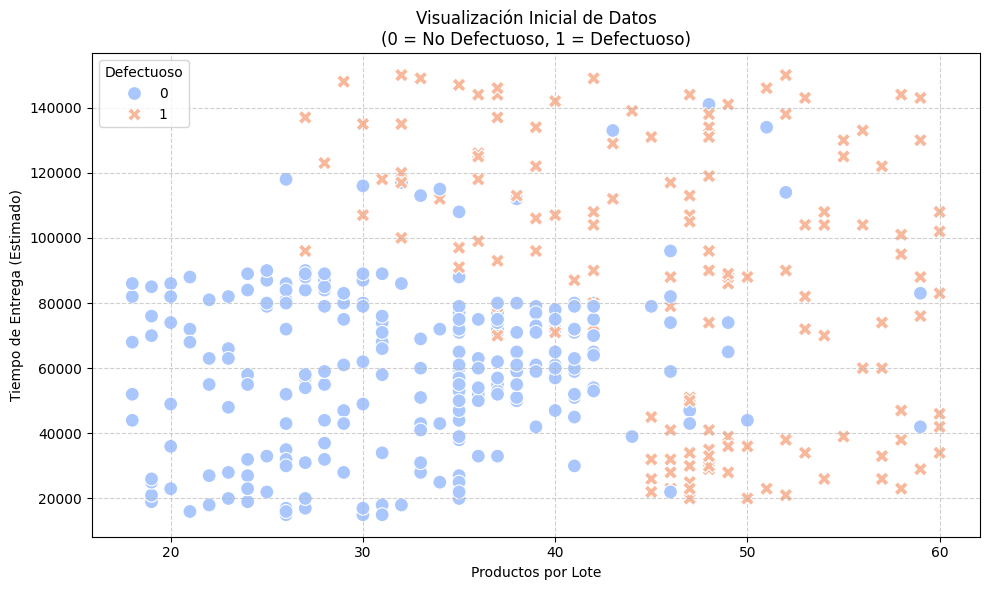

Gráfico 'visualizacion_inicial.png' guardado y mostrado.


In [3]:
# --- Celda 3: (BLOQUE 1) Cargar y Visualizar Datos ---

FILE_NAME = "datos_logisticos.xlsx" # CAMBIAR A LA RUTA DE SU ARCHIVO

try:
    print(f"Cargando datos desde '{FILE_NAME}'...")
    df = pd.read_excel(FILE_NAME)
    print("Datos cargados exitosamente.")
    print(df.head())

    # Visualización inicial
    print("\nGenerando visualización inicial...")
    visualizar_datos_iniciales(df)

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{FILE_NAME}'.")
    print("Asegúrate de haberlo subido al panel izquierdo de Colab.")
except Exception as e:
    print(f"Un error ocurrió al cargar los datos: {e}")

In [4]:
# --- Celda 4: (BLOQUE 2) Preparar y Entrenar Modelo ---

print("Preparando datos para el modelo...")
# 'Muestra' parece ser un índice, no una característica predictiva
feature_columns = ['Productos-Lote', 'Tiempo-Entrega']
X = df[feature_columns]
y = df['Defectuoso']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Total de datos: {len(df)}. Usando {len(X_train)} para entrenar y {len(X_test)} para probar.")

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Datos escalados (se usará StandardScaler).")

# Entrenamiento del Modelo
print("\nEntrenando modelo de Regresión Logística...")
model = LogisticRegression(C=1.0, random_state=42, solver='lbfgs')
model.fit(X_train_scaled, y_train)
print("Modelo entrenado.")
print("Las variables 'model', 'scaler', 'X_train', 'X_test', etc., están listas.")

Preparando datos para el modelo...
Total de datos: 400. Usando 280 para entrenar y 120 para probar.
Datos escalados (se usará StandardScaler).

Entrenando modelo de Regresión Logística...
Modelo entrenado.
Las variables 'model', 'scaler', 'X_train', 'X_test', etc., están listas.


Generando gráfico de la frontera de decisión...


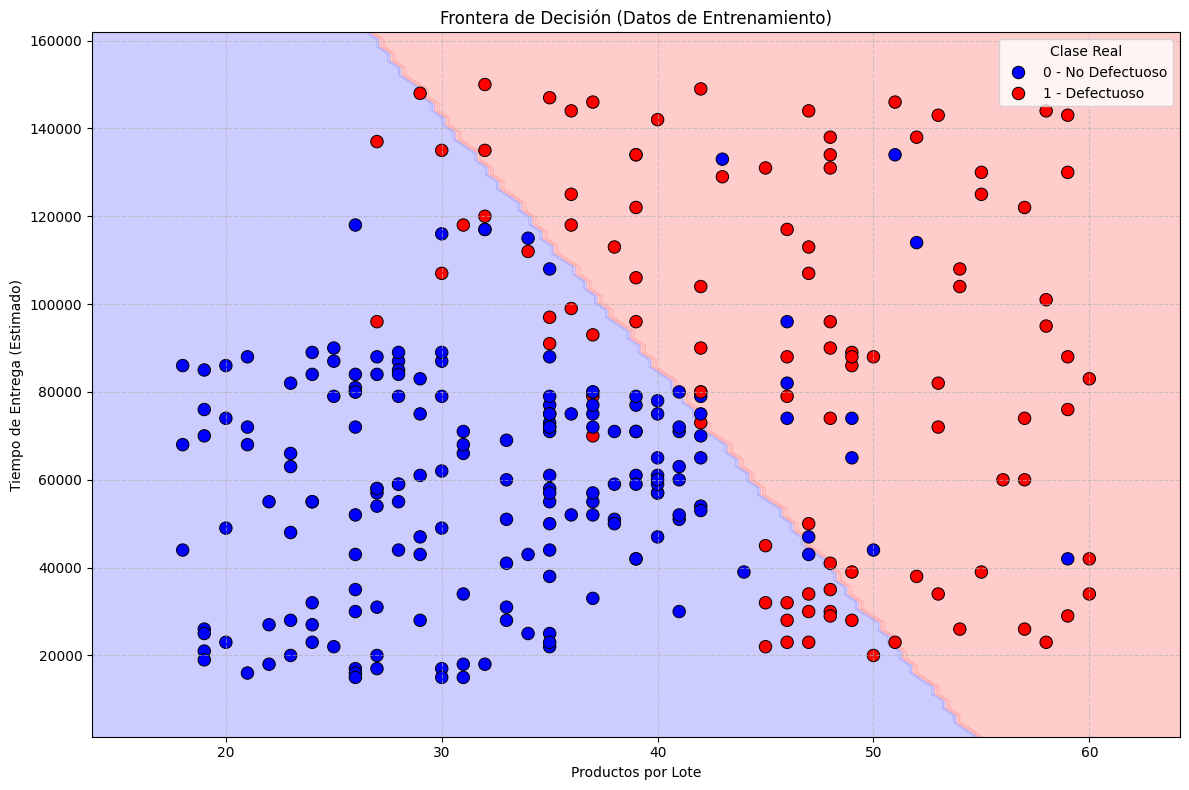

Gráfico 'frontera_decision.png' guardado y mostrado.


In [5]:
# --- Celda 5: (BLOQUE 3) Graficar Frontera de Decisión ---

print("Generando gráfico de la frontera de decisión...")
# Pasamos X_train y y_train originales para graficar los puntos
plot_decision_boundary(X, y, model, scaler, X_train, y_train)

--- MÉTRICAS DE DESEMPEÑO (Sobre datos de PRUEBA) ---
Precisión (Accuracy): 85.00%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        77
           1       0.86      0.70      0.77        43

    accuracy                           0.85       120
   macro avg       0.85      0.82      0.83       120
weighted avg       0.85      0.85      0.85       120


Matriz de Confusión (Datos):
[[72  5]
 [13 30]]

Generando gráfico de Matriz de Confusión...


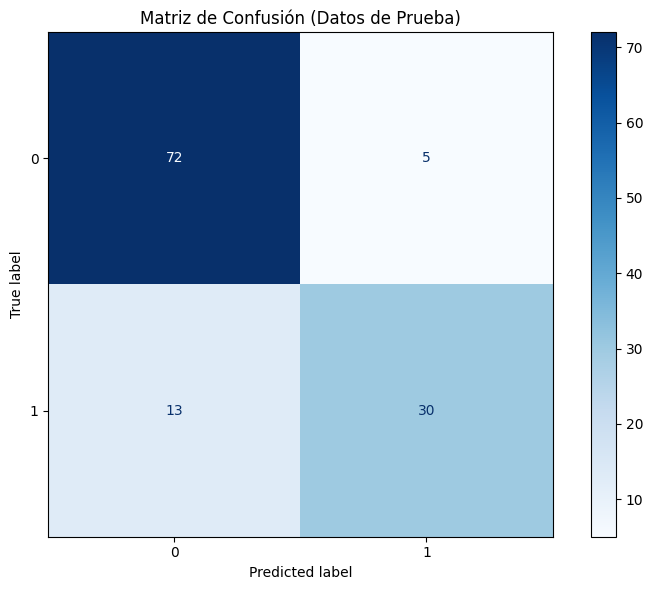

Gráfico 'matriz_confusion.png' guardado y mostrado.


In [6]:
# --- Celda 6: (BLOQUE 4) Calcular Métricas de Desempeño ---

print("--- MÉTRICAS DE DESEMPEÑO (Sobre datos de PRUEBA) ---")
y_pred = model.predict(X_test_scaled)

# Precisión (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión (Accuracy): {accuracy:.2%}")

# Reporte de Clasificación (Precisión, Recall, F1-Score)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de Confusión
print("\nMatriz de Confusión (Datos):")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualizar Matriz de Confusión
print("\nGenerando gráfico de Matriz de Confusión...")
plot_confusion_matrix_metric(y_test, y_pred, labels=model.classes_)

In [7]:
# --- Celda 7: (BLOQUE 5) Predicciones Interactivas ---

# Llamar a la función interactiva (definida en la Celda 2)
predecir_interactivo(model, scaler, feature_columns)


--- PREDICCIONES INTERACTIVAS ---
--- Introduce los datos del nuevo lote ---
Introduce la cantidad 'Productos-Lote' (o 'salir' para terminar): 40
Introduce el 'Tiempo-Entrega': 60000

--- Resultado de la Predicción ---
  > Datos: Productos-Lote=40.0, Tiempo-Entrega=60000.0
  > Resultado: 0 (No Defectuoso)
  > Confianza (No Defectuoso): 71.17%
  > Confianza (Defectuoso):   28.83%
----------------------------------

Introduce la cantidad 'Productos-Lote' (o 'salir' para terminar): salir
Fin del modo de predicción.
